In [82]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

In [83]:
import sys
print(sys.executable)

c:\Users\User\anaconda3\python.exe


In [84]:
import pandas as pd
import os
import kagglehub

# 1. 設定密碼檔案的路徑 (記得加 r 避免路徑反斜線報錯)
token_path = r"C:\Users\User\.kaggle\access_token"

# 2. 讀取密碼檔案的內容，並設定為環境變數
with open(token_path, 'r') as f:
    # .strip() 可以去除字串前後隱藏的換行符號或空白
    os.environ["KAGGLE_API_TOKEN"] = f.read().strip()


# 3. 順利下載或找到已下載的資料集
path = kagglehub.dataset_download("shree0910/buy-now-and-pay-later-fintech-ml-dataset")
print(f"資料集實際存放在：{path}")
print("-" * 40)

# 4. 在下載的資料夾中尋找 CSV 檔案
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    # 組合出完整的 CSV 檔案路徑
    file_path = os.path.join(path, csv_files[0])
    print(f"準備讀取檔案：{file_path}\n" + "-"*40)
    
    # 5. 使用 Pandas 讀取資料
    df = pd.read_csv(file_path)
        
    # 6. 顯示前五筆資料
    display(df.head())
    
else:
    print("在這個資料夾中沒有找到 CSV 檔案喔！")

資料集實際存放在：C:\Users\User\.cache\kagglehub\datasets\shree0910\buy-now-and-pay-later-fintech-ml-dataset\versions\2
----------------------------------------
準備讀取檔案：C:\Users\User\.cache\kagglehub\datasets\shree0910\buy-now-and-pay-later-fintech-ml-dataset\versions\2\Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv
----------------------------------------


,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


## 第一階段：探索性資料分析 (EDA)
EDA 的目的是先摸熟資料，了解欄位型態、分佈與缺失情況，為後續預處理做準備。

In [85]:
# 1. 顯示資料集基本形狀
print("資料筆數與欄位數:", df.shape)

# 2. 欄位型態與 non-null 數量
print("\n欄位型態與非空值數量:")
df.info()

# 3. 缺失值檢查
print("\n缺失值統計:")
display(df.isna().sum())

# 4. 重複資料檢查
print("\n重複資料筆數:", df.duplicated().sum())

# 5. 基本統計摘要（數值與類別欄位）
print("\n數值欄位摘要:")
display(df.describe())

print("\n所有欄位摘要:")
display(df.describe(include='all').T)


資料筆數與欄位數: (10345, 17)

欄位型態與非空值數量:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  transaction_date      10345 non-null  object 
 14  debt_to_income_ratio  10345 non-nul

user_id                 0
age                     0
employment_type         0
monthly_income          0
credit_score            0
purchase_amount         0
product_category        0
bnpl_installments       0
repayment_delay_days    0
missed_payments         0
default_flag            0
app_usage_frequency     0
location                0
transaction_date        0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64


重複資料筆數: 0

數值欄位摘要:


,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000
mean,5173.000000,38.559884,35053.381898,448.176124,3979.402721,7.477525,8.742774,1.015950,0.390527,5.524101,0.181071,198.534094
std,2986.488601,12.131789,27084.517277,136.518332,1500.828483,3.362867,6.781849,0.996726,0.487892,2.590364,0.124887,67.541384
min,1.000000,18.000000,5000.000000,300.000000,100.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000811,0.000000
25%,2587.000000,28.000000,12207.020000,332.000000,2990.720000,3.000000,2.000000,0.000000,0.000000,3.300000,0.080187,153.600000
50%,5173.000000,39.000000,23800.520000,403.000000,5000.000000,9.000000,9.000000,1.000000,0.000000,5.550000,0.138263,202.800000
75%,7759.000000,49.000000,55276.930000,547.000000,5000.000000,9.000000,14.000000,2.000000,1.000000,7.750000,0.268300,250.800000
max,10345.000000,59.000000,145767.120000,850.000000,5000.000000,12.000000,33.000000,7.000000,1.000000,10.000000,0.723460,398.000000



所有欄位摘要:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,10345.0,NaN,NaN,NaN,5173.0,2986.488601,1.0,2587.0,5173.0,7759.0,10345.0
age,10345.0,NaN,NaN,NaN,38.559884,12.131789,18.0,28.0,39.0,49.0,59.0
employment_type,10345,4,Salaried,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_income,10345.0,NaN,NaN,NaN,35053.381898,27084.517277,5000.0,12207.02,23800.52,55276.93,145767.12
credit_score,10345.0,NaN,NaN,NaN,448.176124,136.518332,300.0,332.0,403.0,547.0,850.0
purchase_amount,10345.0,NaN,NaN,NaN,3979.402721,1500.828483,100.0,2990.72,5000.0,5000.0,5000.0
product_category,10345,5,Fashion,2166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bnpl_installments,10345.0,NaN,NaN,NaN,7.477525,3.362867,3.0,3.0,9.0,9.0,12.0
repayment_delay_days,10345.0,NaN,NaN,NaN,8.742774,6.781849,0.0,2.0,9.0,14.0,33.0
missed_payments,10345.0,NaN,NaN,NaN,1.01595,0.996726,0.0,0.0,1.0,2.0,7.0


## 統計學資料型態分類
資料型態可分為：
- **Categorical (類別型)**: 名目型 (nominal) - 無順序，如 employment_type, product_category, location, customer_segment
- **Ordinal (順序型)**: 有順序但間距不明確，如 credit_score (若視為等級)
- **Interval (區間型)**: 有等間距但無絕對零點，如 temperature (此資料集中無明顯範例)
- **Ratio (比率型)**: 有絕對零點，可比較倍數，如 age, monthly_income, purchase_amount 等數值欄位

以下根據欄位內容進行分類：

In [86]:
# 根據統計學分類欄位
data_types = {
    'Categorical': ['employment_type', 'product_category', 'location', 'customer_segment'],  # user_id 不需要
    'Ordinal': ['credit_score'],  # 視為信用等級
    'Interval': ['transaction_date'],  # 時間型欄位歸類為 Interval
    'Ratio': ['age', 'monthly_income', 'purchase_amount', 'bnpl_installments', 
                      'repayment_delay_days', 'missed_payments', 'default_flag', 'app_usage_frequency', 
                      'debt_to_income_ratio', 'risk_score']  
}

# 特殊處理：transaction_date 為日期時間，需轉換
print("資料型態分類：")
for category, columns in data_types.items():
    print(f"\n{category}:")
    for col in columns:
        if col in df.columns:
            dtype = df[col].dtype
            print(f"  - {col} ({dtype})")

# transaction_date 特殊處理
print(f"\n日期時間型: transaction_date ({df['transaction_date'].dtype}) - 建議轉換為 datetime")

資料型態分類：

Categorical:
  - employment_type (object)
  - product_category (object)
  - location (object)
  - customer_segment (object)

Ordinal:
  - credit_score (int64)

Interval:
  - transaction_date (object)

Ratio:
  - age (int64)
  - monthly_income (float64)
  - purchase_amount (float64)
  - bnpl_installments (int64)
  - repayment_delay_days (int64)
  - missed_payments (int64)
  - default_flag (int64)
  - app_usage_frequency (float64)
  - debt_to_income_ratio (float64)
  - risk_score (float64)

日期時間型: transaction_date (object) - 建議轉換為 datetime


## 根據資料型態的統計摘要
不同資料型態適合的統計量不同：
- **Categorical**: 計數、唯一值、最常見值
- **Ordinal**: 計數、平均、中位數、眾數、最小最大
- **Ratio**: 完整統計摘要（平均、標準差等）
- **日期時間型**: 時間範圍、格式檢查

=== Categorical 欄位統計 ===

employment_type:
  類別數量: 4
  最常見值: Salaried (出現 2632 次)
  所有值: {'Salaried': 2632, 'Unemployed': 2632, 'Self-Employed': 2550, 'Student': 2531}


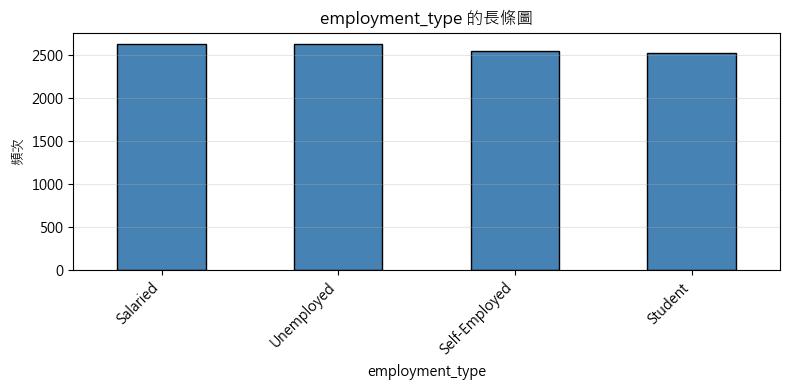


product_category:
  類別數量: 5
  最常見值: Fashion (出現 2166 次)
  所有值: {'Fashion': 2166, 'Electronics': 2085, 'Beauty': 2072, 'Home': 2052, 'Sports': 1970}


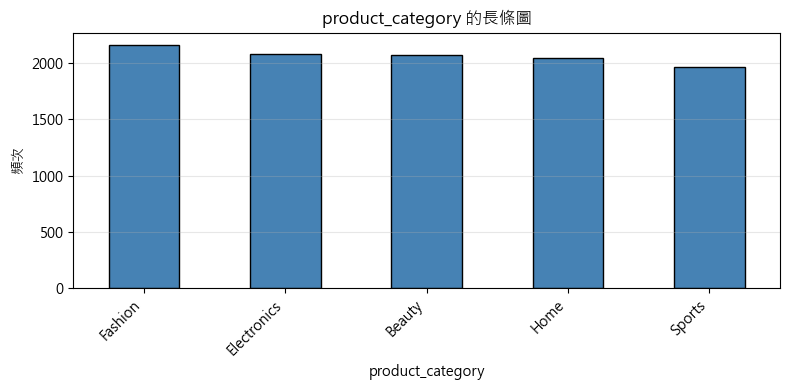


location:
  類別數量: 6
  最常見值: Germany (出現 1760 次)
  所有值: {'Germany': 1760, 'Canada': 1740, 'USA': 1736, 'India': 1723, 'Australia': 1722, 'UK': 1664}


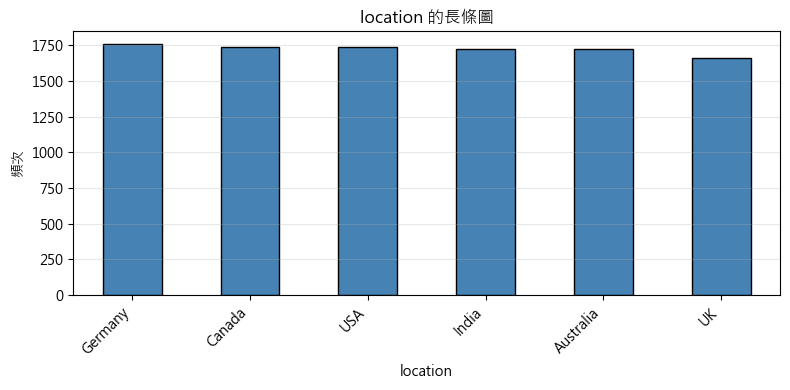


customer_segment:
  類別數量: 3
  最常見值: High Risk (出現 7569 次)
  所有值: {'High Risk': 7569, 'Medium Risk': 2200, 'Low Risk': 576}


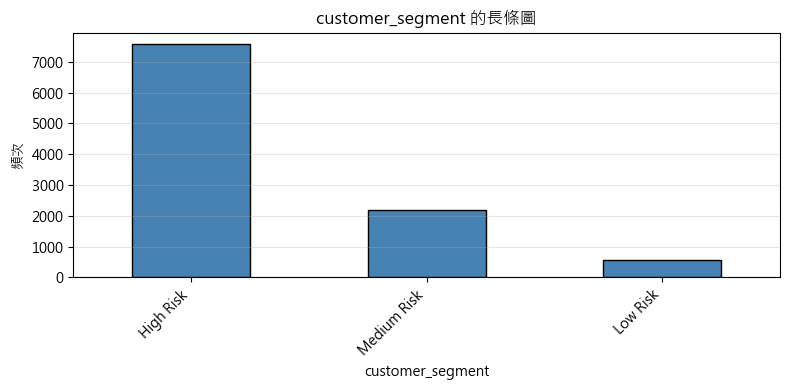

In [87]:
# Categorical統計
print("=== Categorical 欄位統計 ===")
for col in data_types['Categorical']:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  類別數量: {df[col].nunique()}")
        print(f"  最常見值: {df[col].mode().iloc[0]} (出現 {df[col].value_counts().iloc[0]} 次)")
        print(f"  所有值: {df[col].value_counts().to_dict()}")
        
        # 畫長條圖
        plt.figure(figsize=(8, 4))
        df[col].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
        plt.title(f"{col} 的長條圖")
        plt.xlabel(col)
        plt.ylabel('頻次')
        plt.grid(axis='y', alpha=0.3)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

=== Ordinal 欄位統計 ===
Ordinal 欄位清單: ['credit_score']
資料集欄位包含 Ordinal 欄位: ['credit_score']

credit_score:
  計數: 10345
  平均: 448.18
  中位數: 403.00
  眾數: 300
  最小值: 300
  最大值: 850
  標準差: 136.52


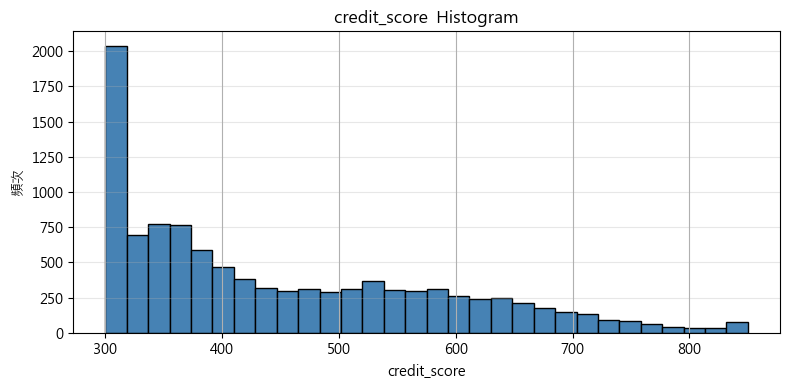

In [88]:
# Ordinal 統計
print("=== Ordinal 欄位統計 ===")
print(f"Ordinal 欄位清單: {data_types['Ordinal']}")
print(f"資料集欄位包含 Ordinal 欄位: {[col for col in data_types['Ordinal'] if col in df.columns]}")
for col in data_types['Ordinal']:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  計數: {df[col].count()}")
        print(f"  平均: {df[col].mean():.2f}")
        print(f"  中位數: {df[col].median():.2f}")
        print(f"  眾數: {df[col].mode().iloc[0]}")
        print(f"  最小值: {df[col].min()}")
        print(f"  最大值: {df[col].max()}")
        print(f"  標準差: {df[col].std():.2f}")
        
        plt.figure(figsize=(8, 4))
        df[col].hist(bins=30, color='steelblue', edgecolor='black')
        plt.title(f"{col}  Histogram")
        plt.xlabel(col)
        plt.ylabel('頻次')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    else:
        print(f"\n! 注意: Ordinal 欄位 '{col}' 不在資料集中，未顯示統計結果。")

=== Ratio 欄位統計 ===

age:


count    10345.000000
mean        38.559884
std         12.131789
min         18.000000
25%         28.000000
50%         39.000000
75%         49.000000
max         59.000000
Name: age, dtype: float64

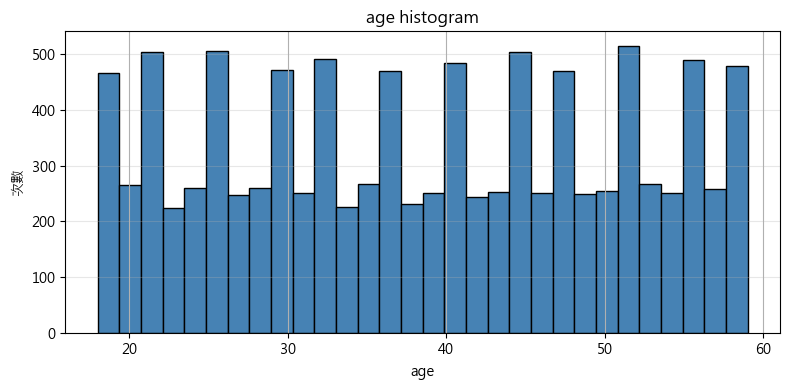


monthly_income:


count     10345.000000
mean      35053.381898
std       27084.517277
min        5000.000000
25%       12207.020000
50%       23800.520000
75%       55276.930000
max      145767.120000
Name: monthly_income, dtype: float64

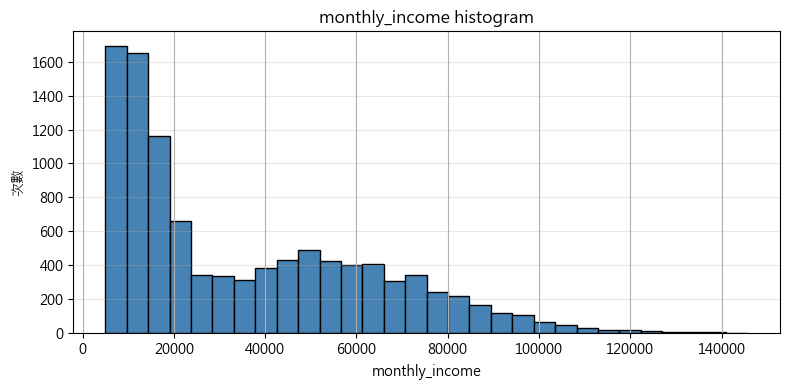


purchase_amount:


count    10345.000000
mean      3979.402721
std       1500.828483
min        100.000000
25%       2990.720000
50%       5000.000000
75%       5000.000000
max       5000.000000
Name: purchase_amount, dtype: float64

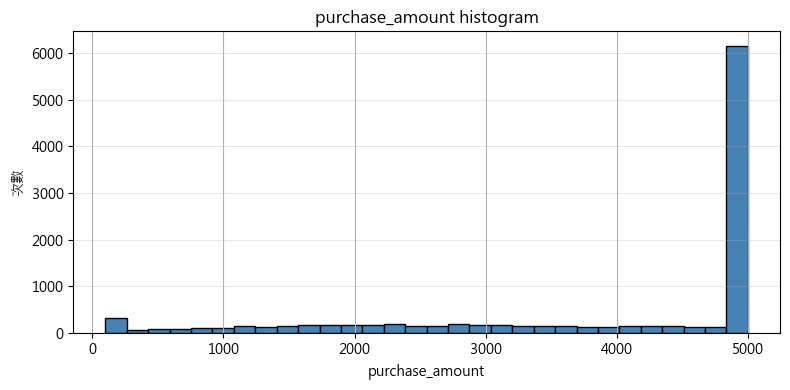


bnpl_installments:


count    10345.000000
mean         7.477525
std          3.362867
min          3.000000
25%          3.000000
50%          9.000000
75%          9.000000
max         12.000000
Name: bnpl_installments, dtype: float64

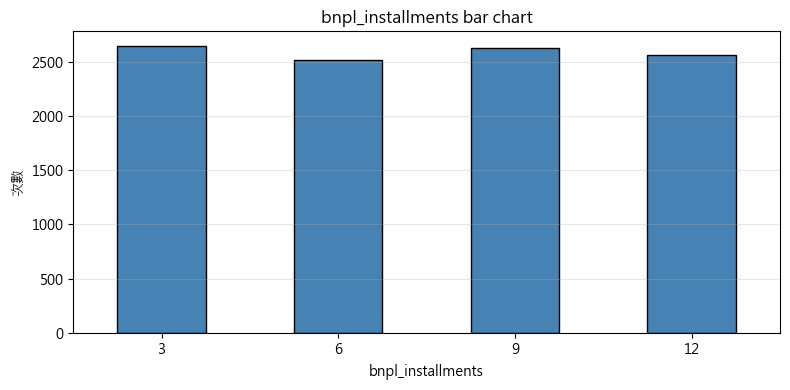


repayment_delay_days:


count    10345.000000
mean         8.742774
std          6.781849
min          0.000000
25%          2.000000
50%          9.000000
75%         14.000000
max         33.000000
Name: repayment_delay_days, dtype: float64

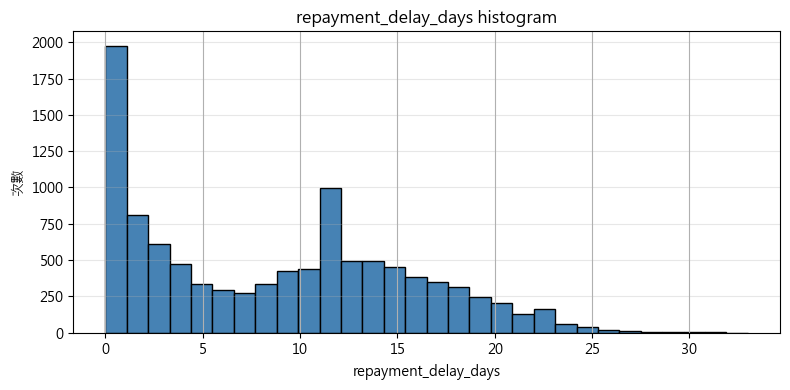


missed_payments:


count    10345.000000
mean         1.015950
std          0.996726
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: missed_payments, dtype: float64

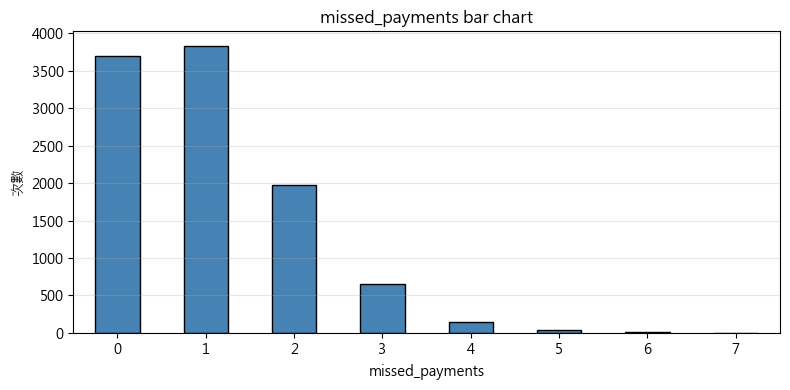


default_flag:


count    10345.000000
mean         0.390527
std          0.487892
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: default_flag, dtype: float64

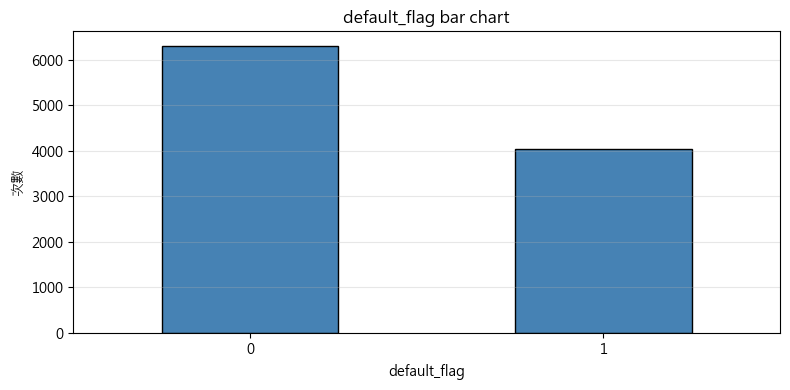


app_usage_frequency:


count    10345.000000
mean         5.524101
std          2.590364
min          1.000000
25%          3.300000
50%          5.550000
75%          7.750000
max         10.000000
Name: app_usage_frequency, dtype: float64

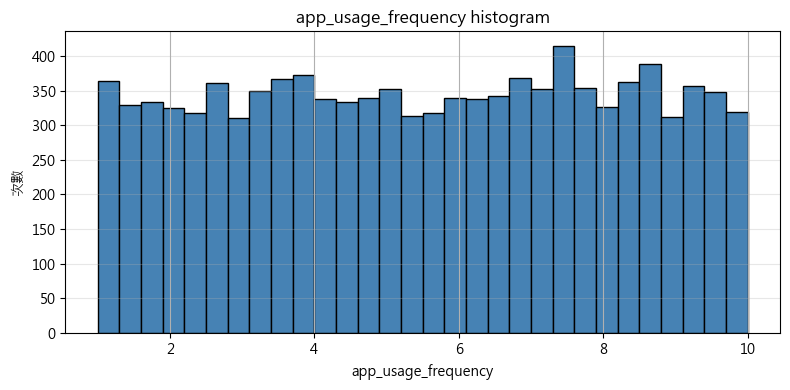


debt_to_income_ratio:


count    10345.000000
mean         0.181071
std          0.124887
min          0.000811
25%          0.080187
50%          0.138263
75%          0.268300
max          0.723460
Name: debt_to_income_ratio, dtype: float64

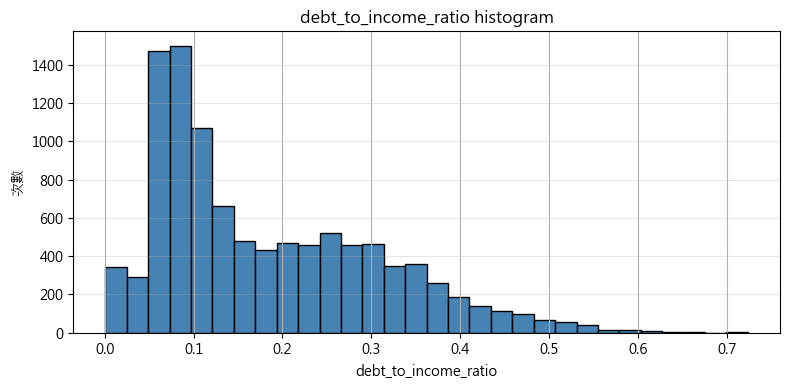


risk_score:


count    10345.000000
mean       198.534094
std         67.541384
min          0.000000
25%        153.600000
50%        202.800000
75%        250.800000
max        398.000000
Name: risk_score, dtype: float64

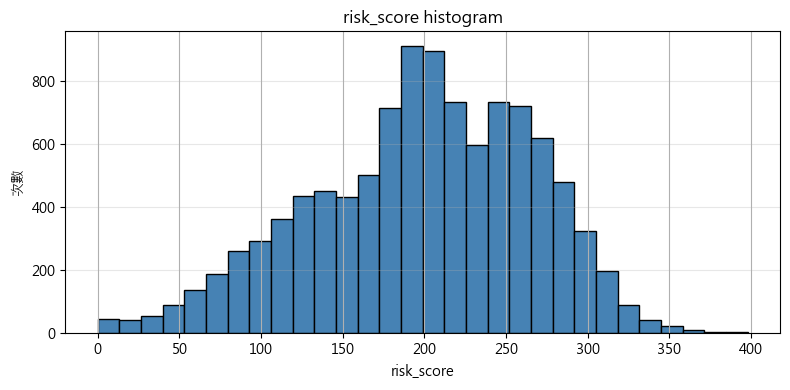

In [89]:
#Ratio統計
print("=== Ratio 欄位統計 ===")
for col in data_types['Ratio']:
    if col in df.columns:
        print(f"\n{col}:")
        display(df[col].describe().T)
        
        # 特殊處理：特定欄位使用長條圖
        if col in ['default_flag', 'missed_payments', 'bnpl_installments']:
            plt.figure(figsize=(8, 4))
            df[col].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
            plt.title(f"{col} bar chart")
            plt.xlabel(col)
            plt.ylabel('次數')
            plt.grid(axis='y', alpha=0.3)
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()
        else:
            # 其他欄位使用直方圖
            plt.figure(figsize=(8, 4))
            df[col].hist(bins=30, color='steelblue', edgecolor='black')
            plt.title(f"{col} histogram")
            plt.xlabel(col)
            plt.ylabel('次數')
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()

=== Interval 欄位統計與時間特徵提取 ===

transaction_date:
  計數: 10345
  開始時間: 2023-01-01 00:00:00
  結束時間: 2024-12-31 00:00:00
  時間跨度: 730 天
  缺失值: 0

  提取的特徵:
    - transaction_date_year
    - transaction_date_month
    - transaction_date_day
    - transaction_date_dayofweek (0=Monday, 6=Sunday)
    - transaction_date_is_weekend (1=Weekend, 0=Weekday)


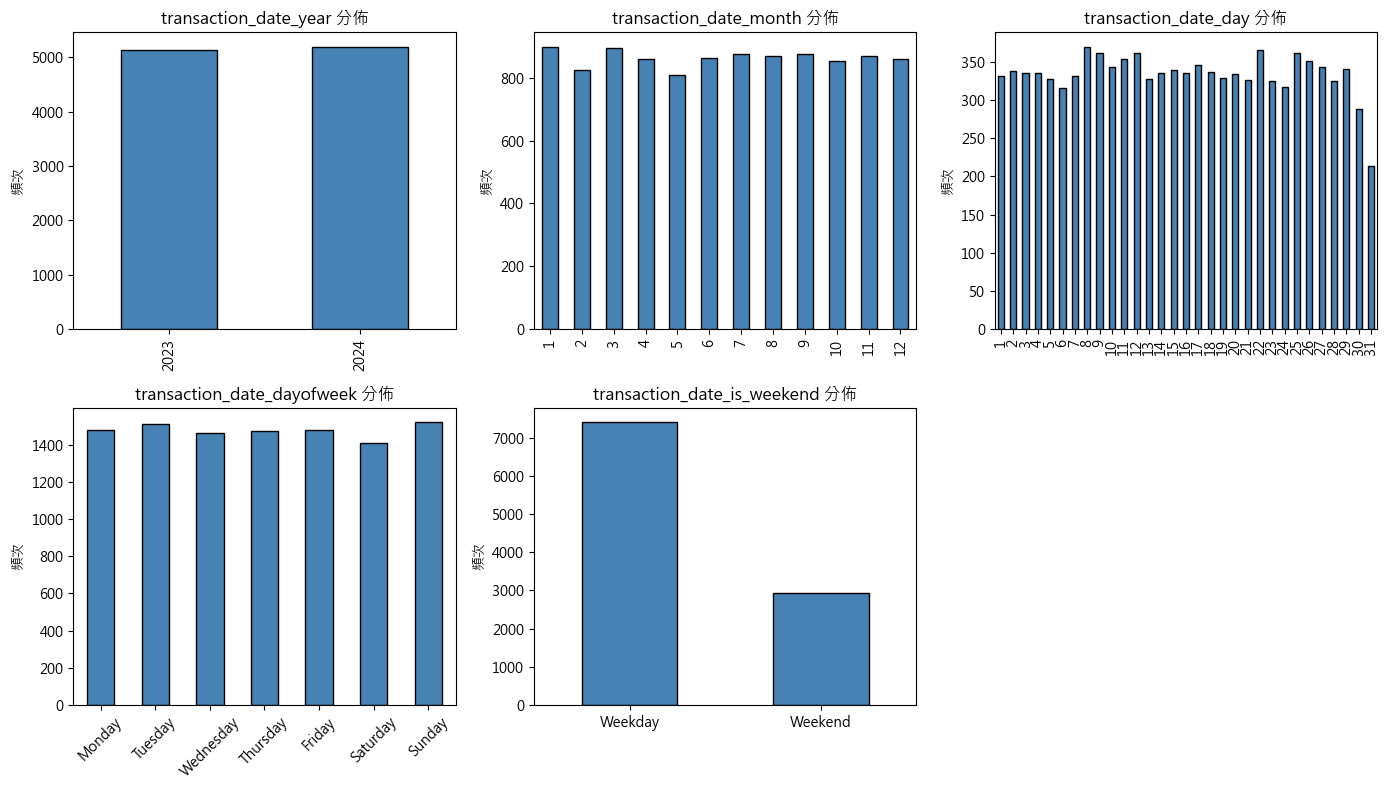

In [90]:
# Interval 統計與時間特徵工程
print("=== Interval 欄位統計與時間特徵提取 ===")
for col in data_types['Interval']:
    if col in df.columns:
        print(f"\n{col}:")
        # 轉換為 datetime 如果還未轉換
        if df[col].dtype == 'object':
            df[col] = pd.to_datetime(df[col], errors='coerce')
        
        # 統計摘要
        print(f"  計數: {df[col].count()}")
        print(f"  開始時間: {df[col].min()}")
        print(f"  結束時間: {df[col].max()}")
        print(f"  時間跨度: {(df[col].max() - df[col].min()).days} 天")
        print(f"  缺失值: {df[col].isna().sum()}")
        
        # 時間特徵工程：提取年、月、日、星期幾、是否週末
        df[f'{col}_year'] = df[col].dt.year
        df[f'{col}_month'] = df[col].dt.month
        df[f'{col}_day'] = df[col].dt.day
        df[f'{col}_dayofweek'] = df[col].dt.dayofweek  # 0=Monday, 6=Sunday
        df[f'{col}_is_weekend'] = df[col].dt.dayofweek.isin([5, 6]).astype(int)  # 1=Weekend, 0=Weekday
        
        print(f"\n  提取的特徵:")
        print(f"    - {col}_year")
        print(f"    - {col}_month")
        print(f"    - {col}_day")
        print(f"    - {col}_dayofweek (0=Monday, 6=Sunday)")
        print(f"    - {col}_is_weekend (1=Weekend, 0=Weekday)")
        
        # 繪製各特徵的分佈
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        
        # Year
        df[f'{col}_year'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
        axes[0, 0].set_title(f'{col}_year 分佈')
        axes[0, 0].set_ylabel('頻次')
        
        # Month
        df[f'{col}_month'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='steelblue', edgecolor='black')
        axes[0, 1].set_title(f'{col}_month 分佈')
        axes[0, 1].set_ylabel('頻次')
        
        # Day
        df[f'{col}_day'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 2], color='steelblue', edgecolor='black')
        axes[0, 2].set_title(f'{col}_day 分佈')
        axes[0, 2].set_ylabel('頻次')
        
        # Day of Week
        day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        df[f'{col}_dayofweek'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='steelblue', edgecolor='black')
        axes[1, 0].set_title(f'{col}_dayofweek 分佈')
        axes[1, 0].set_ylabel('頻次')
        axes[1, 0].set_xticklabels(day_names, rotation=45)
        
        # Is Weekend
        df[f'{col}_is_weekend'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='steelblue', edgecolor='black')
        axes[1, 1].set_title(f'{col}_is_weekend 分佈')
        axes[1, 1].set_xticklabels(['Weekday', 'Weekend'], rotation=0)
        axes[1, 1].set_ylabel('頻次')
        
        # 隱藏最後一個子圖
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()

In [91]:
# 日期時間型欄位處理（已在上面 Interval 統計中完成）
print("=== 日期時間型欄位轉換完成 ===")
print(f"transaction_date 型態: {df['transaction_date'].dtype}")
print(f"時間範圍: {df['transaction_date'].min()} 到 {df['transaction_date'].max()}")
print(f"缺失值: {df['transaction_date'].isna().sum()}")

=== 日期時間型欄位轉換完成 ===
transaction_date 型態: datetime64[ns]
時間範圍: 2023-01-01 00:00:00 到 2024-12-31 00:00:00
缺失值: 0


=== 相關係數分析 ===
employment_type 映射: {'Salaried': 0, 'Self-Employed': 1, 'Student': 2, 'Unemployed': 3}
product_category 映射: {'Beauty': 0, 'Electronics': 1, 'Fashion': 2, 'Home': 3, 'Sports': 4}
location 映射: {'Australia': 0, 'Canada': 1, 'Germany': 2, 'India': 3, 'UK': 4, 'USA': 5}
customer_segment 映射: {'High Risk': 0, 'Low Risk': 1, 'Medium Risk': 2}
transaction_date (原始 datetime 列) 已移除，使用提取的時間特徵代替

分析的欄位: ['user_id', 'age', 'monthly_income', 'credit_score', 'purchase_amount', 'bnpl_installments', 'repayment_delay_days', 'missed_payments', 'default_flag', 'app_usage_frequency', 'debt_to_income_ratio', 'risk_score', 'transaction_date_year', 'transaction_date_month', 'transaction_date_day', 'transaction_date_dayofweek']


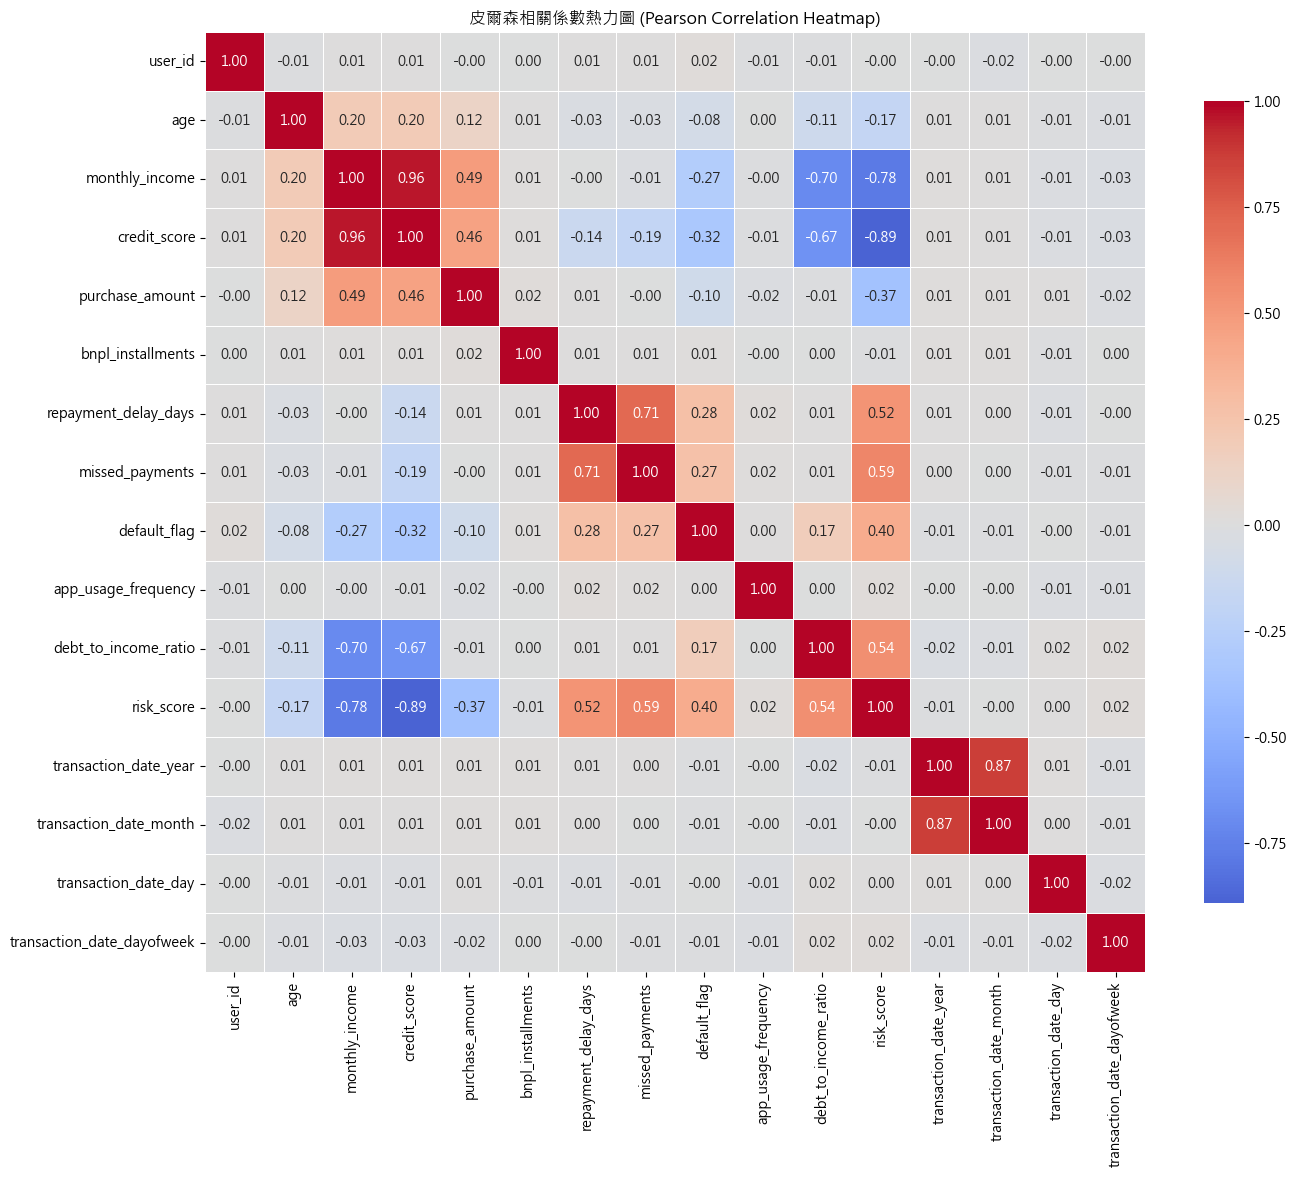

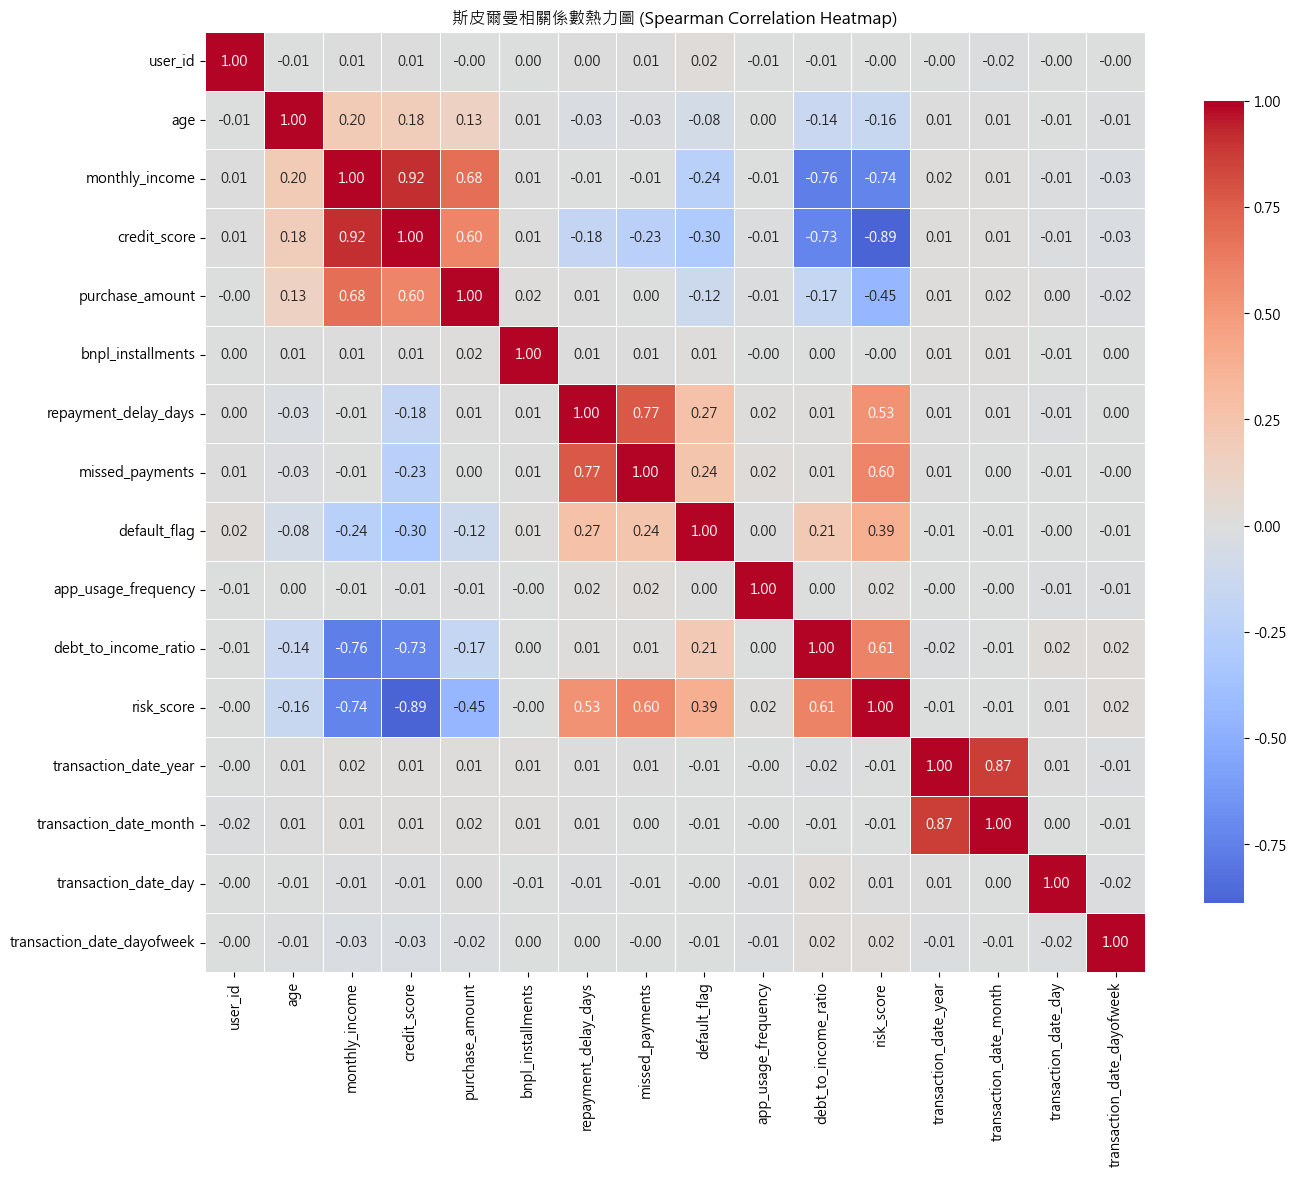


皮爾森相關係數矩陣:


,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score,transaction_date_year,transaction_date_month,transaction_date_day,transaction_date_dayofweek
user_id,1.000000,-0.008591,0.007664,0.007083,-0.002705,0.002276,0.006334,0.009243,0.019243,-0.005798,-0.011393,-0.001727,-0.004828,-0.015787,-0.002143,-0.002035
age,-0.008591,1.000000,0.200800,0.196636,0.120758,0.006152,-0.027326,-0.031063,-0.075702,0.001992,-0.110355,-0.173636,0.009125,0.008110,-0.009721,-0.014856
monthly_income,0.007664,0.200800,1.000000,0.960989,0.488607,0.011245,-0.004013,-0.012604,-0.274163,-0.004985,-0.700067,-0.781487,0.012195,0.007994,-0.012606,-0.027296
credit_score,0.007083,0.196636,0.960989,1.000000,0.457090,0.010336,-0.136305,-0.188617,-0.324238,-0.010793,-0.669564,-0.891544,0.010649,0.007267,-0.012838,-0.027276
purchase_amount,-0.002705,0.120758,0.488607,0.457090,1.000000,0.017927,0.007619,-0.004202,-0.097912,-0.015318,-0.008154,-0.369269,0.011151,0.014668,0.007969,-0.019286
bnpl_installments,0.002276,0.006152,0.011245,0.010336,0.017927,1.000000,0.005590,0.007418,0.012244,-0.002601,0.001426,-0.005044,0.013273,0.012499,-0.010678,0.001547
repayment_delay_days,0.006334,-0.027326,-0.004013,-0.136305,0.007619,0.005590,1.000000,0.713719,0.283209,0.018365,0.009272,0.521674,0.009766,0.004165,-0.014837,-0.000811
missed_payments,0.009243,-0.031063,-0.012604,-0.188617,-0.004202,0.007418,0.713719,1.000000,0.272267,0.017108,0.005638,0.590971,0.003116,0.000832,-0.008906,-0.005216
default_flag,0.019243,-0.075702,-0.274163,-0.324238,-0.097912,0.012244,0.283209,0.272267,1.000000,0.003864,0.172947,0.399379,-0.009408,-0.007563,-0.002956,-0.008672
app_usage_frequency,-0.005798,0.001992,-0.004985,-0.010793,-0.015318,-0.002601,0.018365,0.017108,0.003864,1.000000,0.001565,0.017464,-0.001216,-0.002781,-0.012525,-0.014502



斯皮爾曼相關係數矩陣:


,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score,transaction_date_year,transaction_date_month,transaction_date_day,transaction_date_dayofweek
user_id,1.000000,-0.008680,0.006857,0.006356,-0.002730,0.002285,0.004627,0.007599,0.019243,-0.005624,-0.008901,-0.002963,-0.004828,-0.015718,-0.002005,-0.002048
age,-0.008680,1.000000,0.202487,0.175354,0.129444,0.006057,-0.027591,-0.025147,-0.075622,0.001979,-0.137650,-0.157483,0.009178,0.008192,-0.009783,-0.014666
monthly_income,0.006857,0.202487,1.000000,0.917798,0.683467,0.008456,-0.005765,-0.009993,-0.242133,-0.010355,-0.763407,-0.735334,0.018514,0.012486,-0.012424,-0.030123
credit_score,0.006356,0.175354,0.917798,1.000000,0.599005,0.010397,-0.175262,-0.234733,-0.302947,-0.013410,-0.731247,-0.888907,0.014845,0.011648,-0.012902,-0.029929
purchase_amount,-0.002730,0.129444,0.683467,0.599005,1.000000,0.016228,0.008083,0.001119,-0.115649,-0.012417,-0.171407,-0.453112,0.013333,0.015432,0.004726,-0.019748
bnpl_installments,0.002285,0.006057,0.008456,0.010397,0.016228,1.000000,0.006689,0.006454,0.012234,-0.002730,0.000850,-0.003048,0.013262,0.012521,-0.010661,0.001577
repayment_delay_days,0.004627,-0.027591,-0.005765,-0.175262,0.008083,0.006689,1.000000,0.774901,0.269058,0.018086,0.011994,0.528522,0.009974,0.005112,-0.014652,0.000007
missed_payments,0.007599,-0.025147,-0.009993,-0.234733,0.001119,0.006454,0.774901,1.000000,0.244009,0.019884,0.012274,0.597218,0.007021,0.003798,-0.010109,-0.003537
default_flag,0.019243,-0.075622,-0.242133,-0.302947,-0.115649,0.012234,0.269058,0.244009,1.000000,0.004044,0.214277,0.386206,-0.009408,-0.007569,-0.003165,-0.008667
app_usage_frequency,-0.005624,0.001979,-0.010355,-0.013410,-0.012417,-0.002730,0.018086,0.019884,0.004044,1.000000,0.000793,0.018502,-0.001254,-0.002874,-0.012609,-0.014416


In [92]:
# 相關係數分析
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

print("=== 相關係數分析 ===")

# 建立一個複製的 dataframe 用於編碼
df_encoded = df.copy()

# 編碼 categorical 變數
categorical_cols = data_types['Categorical']
le_dict = {}

for col in categorical_cols:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        le_dict[col] = le
        print(f"{col} 映射: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 移除原始 datetime 欄位，保留提取的時間特徵
interval_cols = data_types['Interval']
for col in interval_cols:
    if col in df_encoded.columns and pd.api.types.is_datetime64_any_dtype(df_encoded[col]):
        # 刪除原始 datetime 列（不用於相關係數計算）
        df_encoded = df_encoded.drop(columns=[col])
        print(f"{col} (原始 datetime 列) 已移除，使用提取的時間特徵代替")

# 選擇所有可用的欄位進行相關係數分析
all_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\n分析的欄位: {all_cols}")

if all_cols:
    # 計算皮爾森相關係數
    pearson_corr = df_encoded[all_cols].corr(method='pearson')
    
    # 計算斯皮爾曼相關係數
    spearman_corr = df_encoded[all_cols].corr(method='spearman')
    
    # 畫皮爾森相關係數熱力圖
    plt.figure(figsize=(14, 12))
    sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, fmt='.2f')
    plt.title('皮爾森相關係數熱力圖 (Pearson Correlation Heatmap)')
    plt.tight_layout()
    plt.show()
    
    # 畫斯皮爾曼相關係數熱力圖
    plt.figure(figsize=(14, 12))
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, fmt='.2f')
    plt.title('斯皮爾曼相關係數熱力圖 (Spearman Correlation Heatmap)')
    plt.tight_layout()
    plt.show()
    
    print("\n皮爾森相關係數矩陣:")
    display(pearson_corr)
    
    print("\n斯皮爾曼相關係數矩陣:")
    display(spearman_corr)
else:
    print("沒有找到可分析的欄位。")